The purpose of this notebook is to generate plots for the required variance in methane forcing to achieve a given variance in the observed methane time series.

In [1]:
from methane_noise_forcing import (
    closed_form,
    average_to_resolution,
    calculate_mean_and_ci,
)
from hydra import compose, initialize
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.gridspec import GridSpec
from pathlib import Path
import pandas as pd
import xarray as xr
import numpy as np
from methane_noise_forcing.core import FirnFilter
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
from methane_noise_forcing.plotting.constants import (
    matplotlib_rcparams,
    fig_width_options,
    colors_vibrant,
    colors_discrete,
)
from methane_noise_forcing.noise import simulate_two_timescale_ar1
from scipy.stats import gaussian_kde

plt.rcParams.update(matplotlib_rcparams)

In [2]:
## figure settings
fig_width = fig_width_options["one_column"]

In [3]:
with initialize(
    version_base=None, config_path="../../configs"
):  # configs with data paths
    cfg = compose(
        config_name="config",
        overrides=[
            "+noise=white_noise_ar1",
            "++noise.duration_timeseries=4750",
            "+firn_kernel=firn_model_wais",
        ],
    )

In [4]:
## global parameters
variance_filtered_methane = 100  # ppb^2
taus_methane = np.arange(7, 13.2, 0.2)  # years

# parameters for sweeping forcing timescale
a, b = -2, 3  # log10 years
m = 10  # samples per decade
num = (b - a) * m + 1  # number of samples
taus_forcing = np.logspace(a, b, num)  # years

# lags to calculate
n_lag_years = 80  # number of year lags to calculate

In [5]:
## plotting functions
def plot_da_heat(
    da,
    *,
    ax=None,  # main plotting axes
    cbar_ax=None,  # optional separate axes for the colorbar
    cmap="Reds",
    log_color=False,  # True => LogNorm for both image & colorbar
    vmin=None,
    vmax=None,
    cbar_label=None,
    cbar_orientation="vertical",  # 'vertical' or 'horizontal'
    tight=False,
    **kwargs,
):
    """
    da: xarray.DataArray with dims ('taus_methane', 'taus_forcing')
    Returns: (h, ax, cbar)
    """
    if ax is None:
        ax = plt.gca()

    # Norm controls both the image mapping and the colorbar scale
    norm = mcolors.LogNorm(vmin=vmin, vmax=vmax) if log_color else None

    # Build kwargs for xarray's plot
    plot_kwargs = dict(
        x="taus_forcing",
        y="taus_methane",
        ax=ax,
        cmap=cmap,
        norm=norm,
        add_colorbar=True,
    )
    if cbar_ax is not None:
        plot_kwargs["cbar_ax"] = cbar_ax
    # Only pass cbar_kwargs if we actually set something, to avoid overriding defaults
    cbar_kwargs = {}
    if cbar_label is not None:
        cbar_kwargs["label"] = cbar_label
    if cbar_orientation != "vertical":
        cbar_kwargs["orientation"] = cbar_orientation
    if cbar_kwargs:
        plot_kwargs["cbar_kwargs"] = cbar_kwargs

    plot_kwargs.update(kwargs)
    h = da.plot(**plot_kwargs)

    # Axes formatting
    ax.set_xscale("log")
    ax.set_xlabel("Forcing timescale (yr)")
    ax.set_ylabel("Methane lifetime (yr)")
    ax.set_title("")

    # Decimal tick labels on a log x-axis (0.01, 0.1, 1, 10, ...)
    ax.xaxis.set_major_locator(mticker.LogLocator(base=10))
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, pos: f"{v:g}"))
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())

    if tight:
        plt.tight_layout()

    # Grab the colorbar (xarray attaches it to the artist)
    cbar = h.colorbar
    return h, ax, cbar


def colorbar_decade_labels(cbar):
    vmin, vmax = cbar.norm.vmin, cbar.norm.vmax
    lo = int(np.ceil(np.log10(vmin)))
    hi = int(np.floor(np.log10(vmax)))
    ticks = [10**e for e in range(lo, hi + 1)]
    if ticks:  # only set if we actually have full decades in-range
        cbar.set_ticks(ticks)
    cbar.formatter = mticker.FuncFormatter(lambda v, pos: f"{v:g}")  # 1, 10, 100...
    cbar.update_ticks()

# generate and visualize kernel self-overlap (autocorrelation)

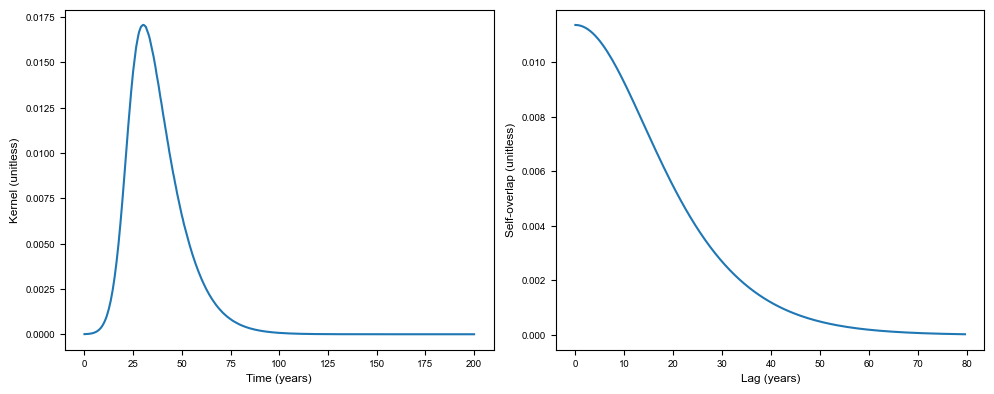

In [6]:
firn_filter = FirnFilter.fit_from_config(
    kernel_type=cfg.firn_kernel.type,
    parameters=cfg.firn_kernel.parameters,
    path_root=cfg.paths.firn_filters_root,
)
# firn_filter = FirnFilter.fit_gamma(
#     mode=30,
#     fwhm=27,
#     skew=0.7,
#     t_max=200,
#     dt=0.1,
#     taper_fraction=0
# )

dt = firn_filter.dt  # years
lags = np.arange(0, n_lag_years / dt, 1)  # years

# normalize kernel by ensuring unit area
# since series dt is equal to kernel dt, we can use the sum of the kernel directly
kernel_normalized = firn_filter.kernel / np.sum(firn_filter.kernel)

# calculate self-overlap
c_taus = closed_form.calculate_kernel_self_lag(
    kernel=kernel_normalized,
    lags=lags,
)

# plot
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# plot firn filter
time = np.arange(0, kernel_normalized.shape[0] * dt, dt)
axs[0].plot(time, kernel_normalized)
axs[0].set_xlabel("Time (years)")
axs[0].set_ylabel("Kernel (unitless)")

# plot self-overlap
axs[1].plot(lags * dt, c_taus)
axs[1].set_xlabel("Lag (years)")
axs[1].set_ylabel("Self-overlap (unitless)")

plt.tight_layout()

# two-timescale noise

## generate autocorrelations for range of timescales

In [7]:
## iterate over methane lifetimes and forcing timescales to calculate autocorrelation over all lags
#  dimensions of output DataSet: (taus_methane, taus_forcing, lags)
autocorrelation_two_timescale = xr.DataArray(
    np.zeros((len(taus_methane), len(taus_forcing), len(lags))),
    dims=["taus_methane", "taus_forcing", "lags"],
    coords={
        "taus_methane": taus_methane,
        "taus_forcing": taus_forcing,
        "lags": lags,
    },
)
for tau_methane in taus_methane:
    for tau_forcing in taus_forcing:
        autocorrelation = closed_form.calculate_two_timescale_autocorrelation(
            phi_0=np.exp(-dt / tau_methane),
            phi_1=np.exp(-dt / tau_forcing),
            lags=lags,
        )
        autocorrelation_two_timescale.loc[
            dict(
                taus_methane=tau_methane,
                taus_forcing=tau_forcing,
            )
        ] = autocorrelation

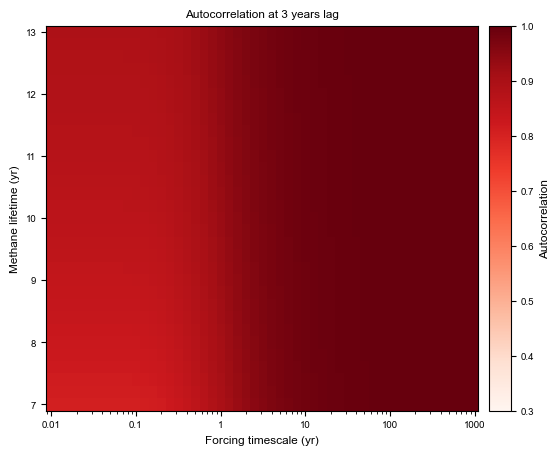

In [8]:
## plot autocorrelations at specific lags
lag_years = 3  # years
da_to_plot = autocorrelation_two_timescale.sel(lags=lag_years)

fig = plt.figure(figsize=(6, 5))
gs = fig.add_gridspec(ncols=2, nrows=1, width_ratios=[20, 1], wspace=0.05)
ax = fig.add_subplot(gs[0, 0])
cax = fig.add_subplot(gs[0, 1])

h, ax, cbar = plot_da_heat(
    da_to_plot,
    ax=ax,
    cbar_ax=cax,
)
h.set_clim(0.3, 1)
h.set_label("something")
ax.set_title(f"Autocorrelation at {lag_years} years lag")
cbar = h.colorbar
cbar.set_label("Autocorrelation")

## calculate variance required in atmospheric methane and forcing

In [9]:
## iterate over methane lifetimes and forcing timescales to calculate atmospheric methane and forcing variances
#  dimensions of output DataSet: (taus_methane, taus_forcing)
atmospheric_methane_variance = xr.DataArray(
    np.zeros((len(taus_methane), len(taus_forcing))),
    dims=["taus_methane", "taus_forcing"],
    coords={
        "taus_methane": taus_methane,
        "taus_forcing": taus_forcing,
    },
)
forcing_variance = xr.DataArray(
    np.zeros((len(taus_methane), len(taus_forcing))),
    dims=["taus_methane", "taus_forcing"],
    coords={
        "taus_methane": taus_methane,
        "taus_forcing": taus_forcing,
    },
)
for tau_methane in taus_methane:
    for tau_forcing in taus_forcing:
        variance_ratio_filtered_to_atmospheric = (
            closed_form.calculate_variance_ratio_filtered_to_instantaneous(
                c_taus=c_taus,
                instantaneous_autocorrelations=autocorrelation_two_timescale.loc[
                    dict(
                        taus_methane=tau_methane,
                        taus_forcing=tau_forcing,
                    )
                ],
            )
        )
        variance_atmospheric_methane = (
            variance_filtered_methane / variance_ratio_filtered_to_atmospheric
        )
        atmospheric_methane_variance.loc[
            dict(
                taus_methane=tau_methane,
                taus_forcing=tau_forcing,
            )
        ] = variance_atmospheric_methane

        variance_ratio_methane_to_forcing = (
            closed_form.calculate_two_timescale_variance_ratio_methane_to_ar1_forcing(
                tau_methane=tau_methane,
                tau_forcing=tau_forcing,
            )
        )
        variance_forcing = (
            variance_atmospheric_methane / variance_ratio_methane_to_forcing
        )
        forcing_variance.loc[
            dict(
                taus_methane=tau_methane,
                taus_forcing=tau_forcing,
            )
        ] = variance_forcing

# convert units of variance from ppb^2/yr^2 to Tg^2/yr^2
# 1 ppb = 2.75 Tg of methane
conversion_factor = 2.75
variance_forcing *= conversion_factor**2

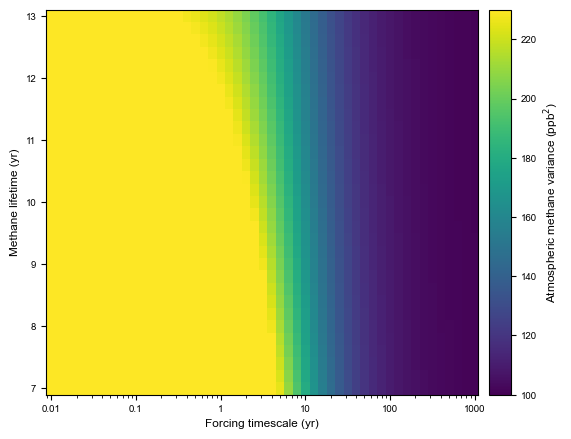

In [10]:
## plot atmospheric methane variance required for a given filtered variance
fig = plt.figure(figsize=(6, 5))
gs = fig.add_gridspec(ncols=2, nrows=1, width_ratios=[20, 1], wspace=0.05)
ax = fig.add_subplot(gs[0, 0])
cax = fig.add_subplot(gs[0, 1])

h, ax, cbar = plot_da_heat(
    atmospheric_methane_variance,
    ax=ax,
    cbar_ax=cax,
    cmap="viridis",
)
cbar = h.colorbar
cbar.set_label("Atmospheric methane variance (ppb$^2$)")
h.set_clim(100, 230)

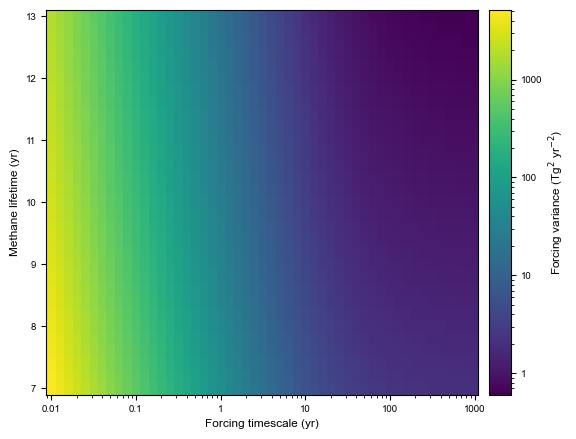

In [11]:
## plot forcing variance required
fig = plt.figure(figsize=(6, 5))
gs = fig.add_gridspec(ncols=2, nrows=1, width_ratios=[20, 1], wspace=0.05)
ax = fig.add_subplot(gs[0, 0])
cax = fig.add_subplot(gs[0, 1])

h, ax, cbar = plot_da_heat(
    forcing_variance,
    ax=ax,
    cbar_ax=cax,
    cmap="viridis",
    log_color=True,
)
cbar = h.colorbar
cbar.set_label("Forcing variance (Tg$^2$ yr$^{-2}$)")
colorbar_decade_labels(cbar)

# compare growth rate to modern methane

In [12]:
data_dir = Path(cfg.paths.observations_cultivated)
obs_modern = pd.read_csv(data_dir / "ch4_growth_modern_detrended.csv")
# absolute value of growth rate
obs_modern["ch4_growth_detrended_abs"] = np.abs(obs_modern["ch4_growth_detrended"])

In [13]:
def simulate_multiple_realizations(
    taus_forcing, var_C_target, tau_C, n_years, dt, n_ensemble
):
    """
    Simulate multiple realizations of methane time series on a grid of
    methane lifetimes (tau_C) x forcing timescales (taus_forcing).

    Parameters
    ----------
    taus_forcing : sequence of float
        Forcing timescales (years), length F.
    var_C_target : float, 1-D array (F,), 2-D array (C,F), or xarray DataArray
        Target methane variance(s) (ppb^2).
        - scalar -> broadcast to (C,F)
        - shape (F,) -> broadcast across tau_C -> (C,F)
        - shape (C,F) -> used as-is
        - if DataArray with dims ('taus_methane','taus_forcing') and/or ('taus_forcing',),
          will be aligned and converted to (C,F) in the order of (tau_C, taus_forcing).
    tau_C : float or sequence of float
        Methane lifetime(s), length C.
    n_years : float
        Total simulation length (years).
    dt : float
        Timestep (years).
    n_ensemble : int
        Number of ensemble members.

    Returns
    -------
    xr.Dataset with dims ('taus_methane','taus_forcing','ensemble','time')
        Variables: 'ch4' and 'forcing'
    """
    # --- normalize axes
    taus_forcing = np.asarray(taus_forcing, dtype=float)
    if not isinstance(tau_C, (list, np.ndarray)):
        tau_C = [tau_C]
    tau_C = np.asarray(tau_C, dtype=float)

    C = tau_C.size
    F = taus_forcing.size

    # --- build time axis
    n_steps = int(np.round(n_years / dt))
    time = np.arange(n_steps) * dt
    ensemble = np.arange(n_ensemble)

    # --- normalize var_C_target to (C, F)
    var_grid = None

    # If xarray DataArray, try to align by coord names
    try:
        import xarray as xr  # in case this function is used standalone

        if isinstance(var_C_target, xr.DataArray):
            da = var_C_target
            # If it has taus dims, reindex/select in provided order; else try to interpret 1-D along forcing
            if "taus_methane" in da.dims and "taus_forcing" in da.dims:
                da = da.sel(
                    taus_methane=xr.DataArray(tau_C, dims="taus_methane"),
                    taus_forcing=xr.DataArray(taus_forcing, dims="taus_forcing"),
                    method="nearest",
                )
                var_grid = da.transpose("taus_methane", "taus_forcing").values
            elif "taus_forcing" in da.dims and da.ndim == 1:
                da = da.sel(
                    taus_forcing=xr.DataArray(taus_forcing, dims="taus_forcing"),
                    method="nearest",
                )
                var_grid = np.broadcast_to(da.values, (C, F))
            else:
                # Fall back to numpy handling below
                pass
    except Exception:
        pass

    if var_grid is None:
        arr = np.asarray(var_C_target, dtype=float)
        if arr.ndim == 0:
            var_grid = np.full((C, F), float(arr))
        elif arr.ndim == 1:
            if arr.shape[0] != F:
                raise ValueError(
                    f"1-D var_C_target must have length {F} (taus_forcing), got {arr.shape[0]}."
                )
            var_grid = np.broadcast_to(arr[None, :], (C, F))
        elif arr.ndim == 2:
            if arr.shape != (C, F):
                raise ValueError(
                    f"2-D var_C_target must have shape {(C, F)} "
                    f"(len(tau_C), len(taus_forcing)), got {arr.shape}."
                )
            var_grid = arr
        else:
            raise ValueError(
                "var_C_target must be scalar, 1-D, 2-D, or an xarray.DataArray with proper dims."
            )

    # --- simulate
    methane_blocks = []
    for i, tau_methane in enumerate(tau_C):
        forcing_blocks = []
        for j, tau_eta in enumerate(taus_forcing):
            var_C = float(var_grid[i, j])

            x_ens, eta_ens = simulate_two_timescale_ar1(
                tau_x=tau_methane,
                tau_eta=tau_eta,
                variance_x=var_C,
                n_steps=n_steps,
                dt=dt,
                n_ens=n_ensemble,
            )

            ds = xr.Dataset(
                {
                    "ch4": (("ensemble", "time"), x_ens),
                    "forcing": (("ensemble", "time"), eta_ens),
                },
                coords={"time": time, "ensemble": ensemble},
            ).expand_dims({"taus_forcing": [tau_eta]})

            forcing_blocks.append(ds)

        ds_for_tau = xr.concat(forcing_blocks, dim="taus_forcing")
        ds_for_tau = ds_for_tau.expand_dims({"taus_methane": [tau_methane]})
        methane_blocks.append(ds_for_tau)

    out = xr.concat(methane_blocks, dim="taus_methane").assign_coords(
        taus_methane=("taus_methane", tau_C),
        taus_forcing=("taus_forcing", taus_forcing),
    )
    return out

In [14]:
taus_forcing = [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
taus_C = [8.0, 10.0, 12.0]
n_ensemble = 100
dt_small = 0.01
n_years = 1000

var_C_target = atmospheric_methane_variance.sel(
    taus_methane=taus_C,
    taus_forcing=taus_forcing,
    method="nearest",
)

two_timescale_noise = simulate_multiple_realizations(
    taus_forcing=taus_forcing,
    var_C_target=var_C_target,  # (C,F) DataArray; function will align/order
    tau_C=taus_C,
    n_years=n_years,
    dt=dt_small,
    n_ensemble=n_ensemble,
)

In [15]:
## average to annual resolution, then calculate growth over some lag
dt_annual = 1.0
change_interval = 1

two_timescale_noise_annual = average_to_resolution(
    two_timescale_noise, resolution=dt_annual, time_dim="time"
)

# lagged difference: x[t] - x[t-lag]
noise_change = two_timescale_noise_annual - two_timescale_noise_annual.shift(
    time=change_interval
)
# drop the leading NaNs introduced by the shift
noise_change = noise_change.isel(time=slice(change_interval, None))

noise_change_abs = np.abs(noise_change)

# validation
ch4_annual_slice = two_timescale_noise_annual.ch4.isel(
    ensemble=0, taus_methane=0, taus_forcing=0
).values
ch4_change_direct = (
    ch4_annual_slice[change_interval:] - ch4_annual_slice[:-change_interval]
)
np.allclose(
    noise_change.ch4.isel(ensemble=0, taus_methane=0, taus_forcing=0).values,
    ch4_change_direct,
)

True

# plot

In [16]:
def annotate_panel(ax, text, loc="left", xpad=0.01, ypad=0.01, color="k", **kwargs):
    """Place bold text at the top-left/right inside an axis."""
    x = xpad if loc == "left" else 1 - xpad
    y = 1 - ypad
    ha = "left" if loc == "left" else "right"
    ax.text(
        x,
        y,
        text,
        transform=ax.transAxes,
        ha=ha,
        va="top",
        fontweight="bold",
        color=color,
        **kwargs,
    )

<>:236: SyntaxWarning: invalid escape sequence '\,'
<>:236: SyntaxWarning: invalid escape sequence '\,'
/tmp/ipykernel_3870474/4174958978.py:236: SyntaxWarning: invalid escape sequence '\,'
  annotate_panel(ax_atmospheric, "σ$_{c'}^2$/σ$_{ice\,core}^2$ (a)", loc="right")


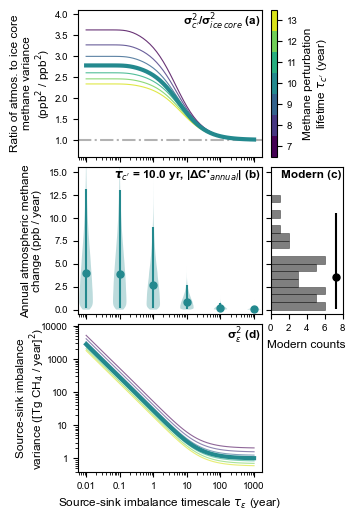

In [17]:
## draft of forcing plot (sweep over methane lifetimes)
# --- Configuration ---
taus_to_plot = np.arange(7, 14)  # 7–13 yr inclusive
tau_methane_mid = 10.0  # main lifetime for panel (b)
xlim = (0.0056, 1778)
xlim_modern = (0, 8)
xticks_modern = (0, 2, 4, 6, 8)
ylim_atmospheric = (0.6, 4.1)
ylim_change_mapper = {
    8.0: (-0.5, 20.5),
    10.0: (-0.5, 15.5),
    12.0: (-0.5, 15.5),
}
ylim_forcing = (0.4, 11000)
density_points = 256
width_decades = 0.2
alpha_fill = 0.3
labelx = -0.25  # x position for y-axis labels
discrete_vals = [9, 10, 14, 15, 17, 18, 26]  # taus to highlight in colors_discrete


def multiplot_params(
    tau, tau_methane_mid=tau_methane_mid, lw_other=0.8, alpha_other=0.7
):
    """ensures line with focus in panel b is thicker, more opaque, and on top"""
    if tau == tau_methane_mid:
        lw = 3
        alpha = 1
        zorder_val = 100
    else:
        lw = lw_other
        alpha = alpha_other
        zorder_val = 1 + 0.01 * tau
    kwargs = dict(lw=lw, alpha=alpha, zorder=zorder_val)
    return kwargs


# --- Colormap for τ sweep ---
# Sample color map at discrete tau values
n_colors = len(taus_to_plot)
cmap_continuous = plt.get_cmap("viridis")
colors_discrete = [
    cmap_continuous(i / (n_colors - 0.6)) for i in range(n_colors)
]  # -1 for full range
cmap = ListedColormap(colors_discrete)

# Define boundaries halfway between tau values
boundaries = np.concatenate(
    [
        [taus_to_plot[0] - 0.5],  # lower bound
        (taus_to_plot[:-1] + taus_to_plot[1:]) / 2,  # midpoints
        [taus_to_plot[-1] + 0.5],  # upper bound
    ]
)
norm = BoundaryNorm(boundaries, cmap.N)

sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
mid_color = cmap(taus_to_plot.tolist().index(tau_methane_mid))

# --- Figure layout ---
fig = plt.figure(figsize=(fig_width_options["one_column"], 3 * 2))
gs = GridSpec(
    nrows=3, ncols=3, width_ratios=[2.9, 0.1, 0.9], figure=fig, hspace=0.07, wspace=0.1
)

# -------------------------------------------------------------------
# (a) Atmospheric methane variance sweep
# -------------------------------------------------------------------
ax_atmospheric = fig.add_subplot(gs[0, 0])
for tau in taus_to_plot:
    da_meth = atmospheric_methane_variance.sel(
        taus_methane=float(tau), method="nearest"
    )
    plot_kwargs = multiplot_params(
        tau, tau_methane_mid=tau_methane_mid, lw_other=0.8, alpha_other=0.8
    )
    ax_atmospheric.plot(
        da_meth.taus_forcing,
        da_meth / variance_filtered_methane,
        color=cmap(norm(tau)),
        **plot_kwargs,
    )
ax_atmospheric.axhline(1, color="k", linestyle="-.", alpha=0.3)
ax_atmospheric.set_xscale("log")
ax_atmospheric.set_xlim(xlim)
ax_atmospheric.set_xticklabels([])
ax_atmospheric.set_ylim(ylim_atmospheric)
ax_atmospheric.set_ylabel(
    "Ratio of atmos. to ice core\nmethane variance\n(ppb$^2$ / ppb$^2$)"
)

# --- Colorbar for τ sweep ---
cax = fig.add_subplot(gs[0, 1])
cb = fig.colorbar(
    sm,
    cax=cax,
    orientation="vertical",
    ticks=taus_to_plot,
    boundaries=boundaries,
    spacing="proportional",
)
cb.set_label("Methane perturbation\nlifetime" + r" $\tau_{c'}$ (year)")
cb.minorticks_off()
cb.ax.yaxis.set_minor_locator(mticker.NullLocator())

# -------------------------------------------------------------------
# (b) Annual methane change (violin) – τ=10
# -------------------------------------------------------------------
ax_change = fig.add_subplot(gs[1, 0])
ax_change.set_xscale("log")
ax_change.set_xlim(xlim)
ax_change.set_ylim(ylim_change_mapper[tau_methane_mid])

for timescale in taus_forcing:
    data = noise_change_abs.ch4.sel(
        taus_methane=tau_methane_mid, taus_forcing=timescale
    ).values.ravel()
    data = data[~np.isnan(data)]
    if data.size == 0:
        continue
    dmin, dmax = np.min(data), np.max(data)
    kde = gaussian_kde(data)
    y = np.linspace(dmin, dmax, density_points)
    v = kde(y)
    v = v / v.max()
    half_width_decades = width_decades * v
    m = 10.0**half_width_decades
    x_left = np.clip(timescale / m, xlim[0], xlim[1])
    x_right = np.clip(timescale * m, xlim[0], xlim[1])
    ax_change.fill_betweenx(
        y, x_left, x_right, facecolor=mid_color, edgecolor="none", alpha=alpha_fill
    )
    mean, ci_lower, ci_upper = calculate_mean_and_ci(
        noise_change_abs.ch4.sel(taus_methane=tau_methane_mid, taus_forcing=timescale),
        dim=["ensemble", "time"],
    )
    median = noise_change_abs.ch4.sel(
        taus_methane=tau_methane_mid, taus_forcing=timescale
    ).median(dim=["ensemble", "time"])
    ax_change.errorbar(
        timescale,
        float(median),
        yerr=[[float(median - ci_lower)], [float(ci_upper - median)]],
        fmt="o",
        markersize=5,
        color=mid_color,
        zorder=10,
    )

ax_change.set_ylabel(f"Annual atmospheric methane\nchange (ppb / year)")
ax_change.set_xticklabels([])

# -------------------------------------------------------------------
# (c) Modern histogram
# -------------------------------------------------------------------
ax_modern = fig.add_subplot(gs[1, 1:])
bin_edges = np.linspace(0, 15, 19)
obs_modern["ch4_growth_detrended_abs"].hist(
    ax=ax_modern,
    bins=bin_edges,
    density=False,
    alpha=0.5,
    orientation="horizontal",
    color="k",
    edgecolor="k",
    linewidth=0.5,
)
median_modern = obs_modern["ch4_growth_detrended_abs"].median()
ci_lower_modern = obs_modern["ch4_growth_detrended_abs"].quantile(0.025)
ci_upper_modern = obs_modern["ch4_growth_detrended_abs"].quantile(0.975)
ax_modern.errorbar(
    7.2,
    float(median_modern),
    yerr=[
        [float(median_modern - ci_lower_modern)],
        [float(ci_upper_modern - median_modern)],
    ],
    fmt="o",
    markersize=5,
    color="k",
    zorder=10,
)
ax_modern.set_ylim(ylim_change_mapper[tau_methane_mid])
ax_modern.set_yticklabels([])
ax_modern.set_xlim(xlim_modern)
ax_modern.set_xticks(xticks_modern)
ax_modern.set_xlabel("Modern counts", labelpad=4.5)
ax_modern.grid(False)

# -------------------------------------------------------------------
# (d) Source/sink variance sweep
# -------------------------------------------------------------------
ax_forcing = fig.add_subplot(gs[2, 0])
for tau in taus_to_plot:
    da_force = forcing_variance.sel(taus_methane=float(tau), method="nearest")
    plot_kwargs = multiplot_params(
        tau, tau_methane_mid=tau_methane_mid, lw_other=0.8, alpha_other=0.6
    )
    ax_forcing.plot(
        da_force.taus_forcing,
        da_force,
        color=cmap(norm(tau)),
        **plot_kwargs,
    )

# # GFDL-CM3 OH point
# ax_forcing.plot(0.13, 14.4, "o", color=colors_vibrant["magenta"], zorder=10)
# ax_forcing.text(
#     0.25,
#     0.30,
#     "GFDL-CM3\nOH",
#     transform=ax_forcing.transAxes,
#     ha="center",
#     va="top",
#     fontweight="bold",
#     color=colors_vibrant["magenta"],
# )

ax_forcing.set_ylabel("Source-sink imbalance\nvariance ([Tg CH$_4$ / year]$^2$)")
ax_forcing.set_ylim(ylim_forcing)
ax_forcing.set_yscale("log")
ax_forcing.yaxis.set_major_locator(mticker.LogLocator(base=10))
ax_forcing.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, pos: f"{v:g}"))
ax_forcing.yaxis.set_minor_formatter(mticker.NullFormatter())
ax_forcing.set_xscale("log")
ax_forcing.set_xlim(xlim)
ax_forcing.set_xlabel(r"Source-sink imbalance timescale $\tau_{\varepsilon}$ (year)")
ax_forcing.xaxis.set_major_locator(mticker.LogLocator(base=10))
ax_forcing.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, pos: f"{v:g}"))
ax_forcing.xaxis.set_minor_formatter(mticker.NullFormatter())

# -------------------------------------------------------------------
# (e) Annotations
# -------------------------------------------------------------------
annotate_panel(ax_atmospheric, "σ$_{c'}^2$/σ$_{ice\,core}^2$ (a)", loc="right")
annotate_panel(
    ax_change,
    r"$\boldsymbol{\tau}_{c'}$ =" + f" {tau_methane_mid} yr, " + "|ΔC'$_{annual}$| (b)",
    loc="right",
)
annotate_panel(ax_modern, "Modern (c)", xpad=0.02, ypad=0.015, loc="right")
annotate_panel(ax_forcing, "σ$_{ε}^2$ (d)", loc="right")

for ax in [ax_atmospheric, ax_change, ax_forcing]:
    ax.yaxis.set_label_coords(labelx, 0.5)
    ax.yaxis.label.set_verticalalignment("center")

# -------------------------------------------------------------------
# Save
# -------------------------------------------------------------------
if tau_methane_mid == 10.0:
    name = f"fig_3"
else:
    name = f"fig_3_tau{int(tau_methane_mid)}"
fig.savefig(
    f"{cfg.paths.figures_dir}/for_publication/{name}.pdf", bbox_inches="tight", dpi=300
)